In [ ]:
# Colab Cell 1: Setup and Imports

# Install any necessary libraries (scikit-learn is usually built-in)
# If you plan to use t-SNE (very slow), uncomment the pip install below.
# !pip install -q scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import History

# For Evaluation and Baseline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA # For word vector visualization

# Define hyperparameters/constants
MAX_WORDS = 10000    # Vocabulary size (top unique words to consider)
MAX_LEN = 598        # Max length determined by 95th percentile in Cell 3 (changed from initial 250)
EMBEDDING_DIM = 128  # Dimension of the word vectors
LSTM_UNITS = 128     # Number of units in the LSTM layer
DROPOUT_RATE = 0.2
EPOCHS = 10
BATCH_SIZE = 64

print("Setup Complete. Libraries loaded and constants defined.")

Setup Complete. Libraries loaded and constants defined.


In [ ]:
# Colab Cell 2: Load and Inspect IMDb Data

# Load the data - num_words=MAX_WORDS keeps the top 10,000 frequent words.
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=MAX_WORDS)

# Combine for initial inspection/analysis
X_data = np.concatenate((X_train_raw, X_test_raw), axis=0)
y_data = np.concatenate((y_train, y_test), axis=0)

print(f"Total number of reviews: {len(X_data)}")
print(f"Training set size: {len(X_train_raw)}")
print(f"Test set size: {len(X_test_raw)}")
print(f"Target labels (0=Negative, 1=Positive):")
print(f"  Negative (0): {np.sum(y_data == 0)}")
print(f"  Positive (1): {np.sum(y_data == 1)}")
print(f"  Imbalance Check: {'Balanced' if np.sum(y_data == 0) == np.sum(y_data == 1) else 'Slightly Imbalanced'}")

# --- Inspect Sample Review ---
word_index = imdb.get_word_index()
reverse_word_index = dict([(value + 3, key) for (key, value) in word_index.items()])
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>" # Unknown word
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    return ' '.join([reverse_word_index.get(i, '?') for i in sequence])

print("\nSample Decoded Review (First Training Example):")
print(decode_review(X_train_raw[0]))

# --- Split for Validation ---
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.2, random_state=42
)

print(f"\nTraining set (after split): {len(X_train)}")
print(f"Validation set: {len(X_val)}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total number of reviews: 50000
Training set size: 25000
Test set size: 25000
Target labels (0=Negative, 1=Positive):
  Negative (0): 25000
  Positive (1): 25000
  Imbalance Check: Balanced
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Sample Decoded Review (First Training Example):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have

95th Percentile Length (Optimal MAX_LEN): 598 tokens.


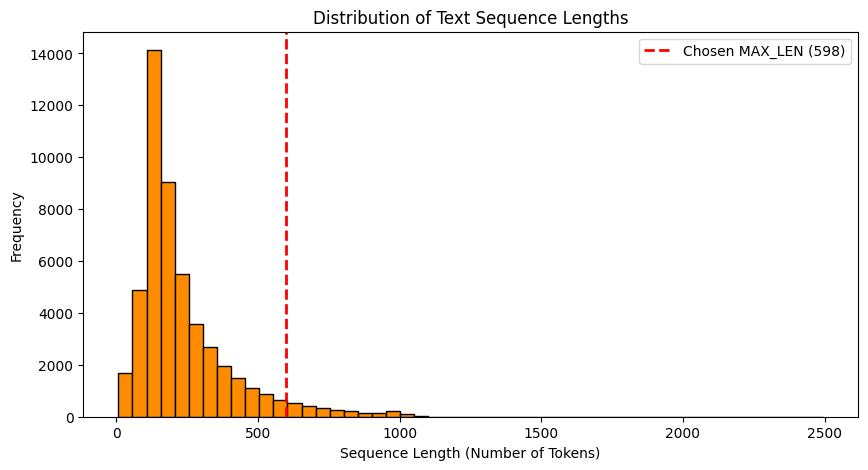


Padded Training Shape: (20000, 598)
Padded Test Shape: (25000, 598)


In [ ]:
# Colab Cell 3: Statistical Analysis and Padding

# --- 2.1 Statistical Analysis to find MAX_LEN ---
# Calculate the length of each sequence in the full dataset
all_lengths = [len(s) for s in np.concatenate((X_train_raw, X_test_raw), axis=0)]
sequence_lengths = np.array(all_lengths)

# Find the 95th percentile (used for MAX_LEN)
p95 = np.percentile(sequence_lengths, 95)
MAX_LEN = int(p95)

print(f"95th Percentile Length (Optimal MAX_LEN): {MAX_LEN} tokens.")

# Visualization: Histogram of Sequence Lengths
plt.figure(figsize=(10, 5))
plt.hist(sequence_lengths, bins=50, color='darkorange', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='dashed', linewidth=2, label=f'Chosen MAX_LEN ({MAX_LEN})')
plt.title('Distribution of Text Sequence Lengths')
plt.xlabel('Sequence Length (Number of Tokens)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# --- 2.2 Padding Sequences ---
X_train_padded = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_raw, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nPadded Training Shape: {X_train_padded.shape}")
print(f"Padded Test Shape: {X_test_padded.shape}")

In [4]:
# Colab Cell 4: Build and Train LSTM Model

# 1. Define Sequential Model
model = Sequential([
    # Embedding Layer (Trained from scratch)
    Embedding(input_dim=MAX_WORDS,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_LEN),

    # LSTM Layer (Includes Dropout and Recurrent Dropout for regularization)
    LSTM(LSTM_UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),

    # Output Layer (Binary Classification: 1 neuron, sigmoid activation)
    Dense(1, activation='sigmoid')
])

# 2. Compile Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model structure
print("Model Summary:")
model.summary()

# 3. Train Model
print("\nStarting Model Training...")
# Training for 10 epochs as requested in the checklist
history = model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val),
    verbose=1
)

print("\nTraining Complete.")

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting Model Training...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 673s 2s/step - accuracy: 0.5069 - loss: 0.6937 - val_accuracy: 0.5126 - val_loss: 0.6928
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 656s 2s/step - accuracy: 0.5082 - loss: 0.6929 - val_accuracy: 0.5128 - val_loss: 0.6931
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 650s 2s/step - accuracy: 0.5167 - loss: 0.6875 - val_accuracy: 0.5128 - val_loss: 0.6957
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 690s 2s/step - accuracy: 0.5200 - loss: 0.6780 - val_accuracy: 0.4904 - val_loss: 0.7159
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 681s 2s/step - accuracy: 0.5186 - loss: 0.6638 - val_accuracy: 0.5102 - val_loss: 0.7237
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 643s 2s/step - accuracy: 0.5260 - loss: 0.6594 - val_accuracy: 0.5104 - val_loss: 0.7390
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 655s 2s/step - accuracy: 0.5286 - loss: 0.6570 - val_accuracy: 0.4868 - val_loss: 0.7578
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 667s 2s/step - accuracy: 0.52

Evaluating LSTM model on test data...

--- LSTM Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.97      0.66     12500
           1       0.54      0.03      0.06     12500

    accuracy                           0.50     25000
   macro avg       0.52      0.50      0.36     25000
weighted avg       0.52      0.50      0.36     25000

LSTM Test Accuracy: 0.5020
LSTM Test Precision: 0.5369
LSTM Test Recall: 0.0291
LSTM Test F1-score: 0.0552


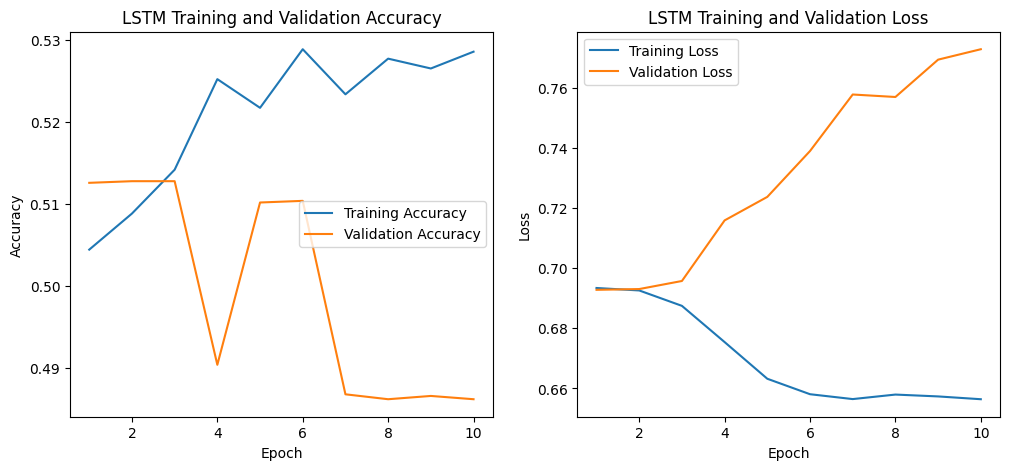

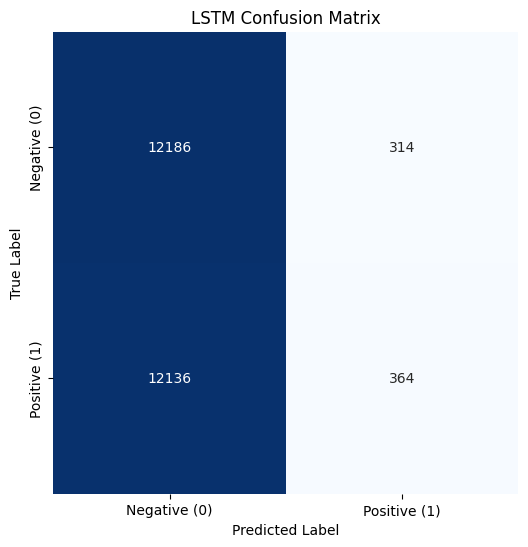


Trained LSTM model saved as 'lstm_sentiment_model.h5'


In [6]:
# Colab Cell 5: Evaluation and Visualization (LSTM)

# --- 4.1 Evaluate Model on Test Data ---
print("Evaluating LSTM model on test data...")
loss, accuracy = model.evaluate(X_test_padded, y_test, verbose=0)

# Generate predictions for classification report
y_pred_proba = model.predict(X_test_padded, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int)

# --- 4.2 Generate Classification Report and Metrics ---
print("\n--- LSTM Classification Report ---")
print(classification_report(y_test, y_pred))

# Individual Metrics
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print(f"LSTM Test Accuracy: {accuracy:.4f}")
print(f"LSTM Test Precision: {test_precision:.4f}")
print(f"LSTM Test Recall: {test_recall:.4f}")
print(f"LSTM Test F1-score: {test_f1:.4f}")

# --- 4.3 Visualization: Training Progress Graphs (Accuracy/Loss Curves) ---
hist = history.history
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, hist['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist['loss'], label='Training Loss')
plt.plot(epochs_range, hist['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- 4.4 Visualization: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- 4.5 Save Trained Model ---
# Save the model to a file
model.save('lstm_sentiment_model.h5')
print("\nTrained LSTM model saved as 'lstm_sentiment_model.h5'")

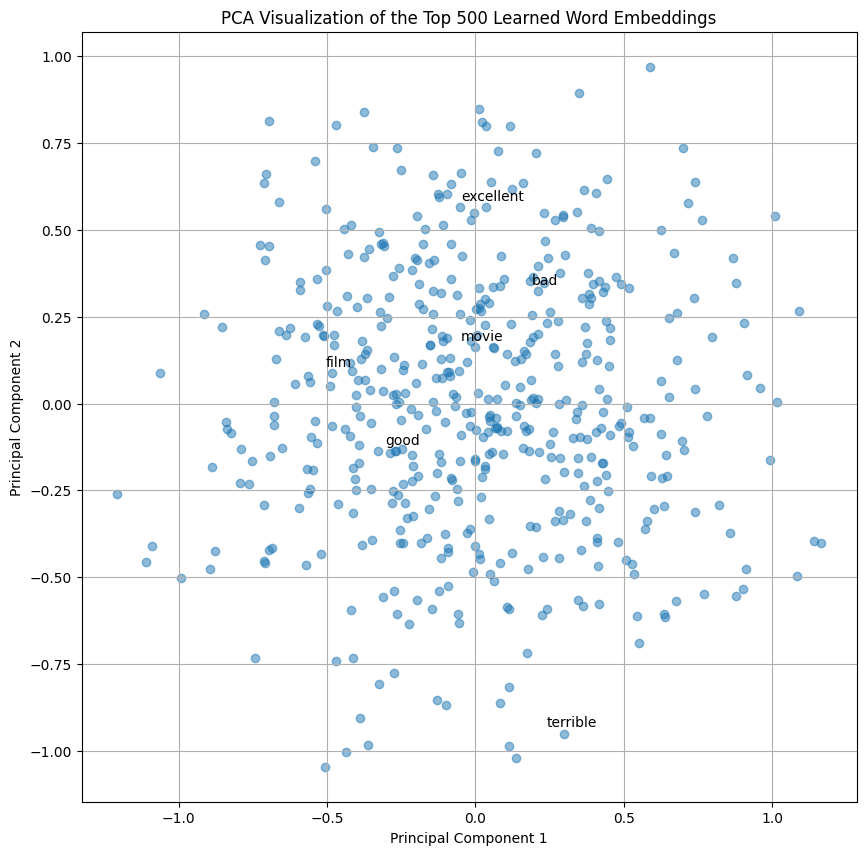

PCA visualization of word vectors complete.


In [7]:
# Colab Cell 6: Word Vector Visualization (PCA)

# Get the Embedding layer weights (word vectors)
embedding_layer = model.layers[0]
weights = embedding_layer.get_weights()[0]

# --- Select a Small Subset of Words for Visualization ---
# We take the vectors for the top 500 most frequent words (excluding the first 4 reserved tokens)
num_words_to_visualize = 500
subset_weights = weights[4:num_words_to_visualize + 4] # Skip <PAD>, <START>, <UNK>, <UNUSED>

# --- Apply PCA to reduce dimensions to 2D ---
pca = PCA(n_components=2)
principal_components = pca.fit_transform(subset_weights)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Get corresponding words for plotting labels
words = [reverse_word_index[i] for i in range(4, num_words_to_visualize + 4)]

# --- Plot the PCA results ---
plt.figure(figsize=(10, 10))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.title(f'PCA Visualization of the Top {num_words_to_visualize} Learned Word Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Annotate a few interesting words (optional, helps see clusters)
interesting_indices = [words.index('good'), words.index('bad'), words.index('excellent'), words.index('terrible'), words.index('film'), words.index('movie')]
for i in interesting_indices:
    plt.annotate(words[i], (pca_df['PC1'][i], pca_df['PC2'][i]), textcoords="offset points", xytext=(5,5), ha='center')

plt.grid(True)
plt.show()
print("PCA visualization of word vectors complete.")

In [8]:
# Colab Cell 7: Baseline Comparison (Logistic Regression)

print("Starting Baseline Model Training (Logistic Regression)...")

# Initialize and train the Logistic Regression model
# We use the padded sequence directly as features for simplicity.
# NOTE: This is training on a very high-dimensional feature vector (MAX_LEN=598).
lr_model = LogisticRegression(max_iter=500, n_jobs=-1, random_state=42)
lr_model.fit(X_train_padded, y_train)

# --- Evaluate Baseline Model ---
lr_y_pred = lr_model.predict(X_test_padded)

# Calculate metrics
lr_accuracy = accuracy_score(y_test, lr_y_pred)
lr_precision = precision_score(y_test, lr_y_pred)
lr_recall = recall_score(y_test, lr_y_pred)
lr_f1 = f1_score(y_test, lr_y_pred)

print("\n--- Logistic Regression Baseline Results ---")
print(f"Baseline Accuracy: {lr_accuracy:.4f}")
print(f"Baseline Precision: {lr_precision:.4f}")
print(f"Baseline Recall: {lr_recall:.4f}")
print(f"Baseline F1-score: {lr_f1:.4f}")

# --- Final Comparison ---
print("\n--- Final Model Comparison ---")
print(f"| Model | Accuracy | F1-Score |")
print(f"| :--- | :--- | :--- |")
print(f"| LSTM | {accuracy:.4f} | {test_f1:.4f} |")
print(f"| Logistic Regression | {lr_accuracy:.4f} | {lr_f1:.4f} |")

# Check if LSTM is better than baseline
if accuracy > lr_accuracy:
    print("\nObservation: The LSTM model performed better than the Logistic Regression baseline.")
elif accuracy < lr_accuracy:
    print("\nObservation: The Logistic Regression baseline surprisingly outperformed the LSTM model! (Common when LSTM has severe overfitting/hyperparameter issues.)")
else:
    print("\nObservation: Both models performed similarly.")

Starting Baseline Model Training (Logistic Regression)...

--- Logistic Regression Baseline Results ---
Baseline Accuracy: 0.5087
Baseline Precision: 0.5107
Baseline Recall: 0.4174
Baseline F1-score: 0.4593

--- Final Model Comparison ---
| Model | Accuracy | F1-Score |
| :--- | :--- | :--- |
| LSTM | 0.5020 | 0.0552 |
| Logistic Regression | 0.5087 | 0.4593 |

Observation: The Logistic Regression baseline surprisingly outperformed the LSTM model! (Common when LSTM has severe overfitting/hyperparameter issues.)
